In [22]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report , confusion_matrix

## For heart Diease Priority for Recall score (type 2 error)

In [16]:
# Loading the Data
df = pd.read_csv("1-heart.csv")

In [17]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [18]:
df.info() 
df.isnull().sum()
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [19]:
X=df.drop("target",axis=1)
y=df["target"]

In [21]:
# Train test Split
X_train,X_test,Y_train,Y_test = train_test_split(
    X,y,random_state=42,test_size=0.3,stratify=y
)

# LogisticRegression 

In [27]:
from sklearn.linear_model import LogisticRegression 
model=LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

LR_test = accuracy_score(Y_test,Y_pred)
LR_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {LR_test}')
print(f'training acc : {LR_train}')


testing acc : 0.7472527472527473
training acc : 0.8773584905660378


## Using some Hypertuning  and Feature Engineering- LogisticRegression  

In [66]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("scaler",StandardScaler()),
    ("lr",LogisticRegression(max_iter=1000))
])

param={"lr__solver":["lbfgs","liblinear","sag","saga"]}

model = GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param,
    scoring="recall"
)
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)
Y_tpred = model.predict(X_train)

LR_test = accuracy_score(Y_test,Y_pred)
LR_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(LR_test)*100} %\n')
print(f'training acc : {(LR_train)*100} %\n')

res=pd.DataFrame(model.cv_results_)

print(model.best_params_)
print(f'\n{confusion_matrix(Y_test,Y_pred)}\n')
print(f'{classification_report(Y_test,Y_pred)}\n')

res[["param_lr__solver","mean_test_score"]]

testing acc : 75.82417582417582 %

training acc : 87.26415094339622 %

{'lr__solver': 'lbfgs'}

[[28 13]
 [ 9 41]]

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        41
           1       0.76      0.82      0.79        50

    accuracy                           0.76        91
   macro avg       0.76      0.75      0.75        91
weighted avg       0.76      0.76      0.76        91




,param_lr__solver,mean_test_score
0,lbfgs,0.886957
1,liblinear,0.886957
2,sag,0.886957
3,saga,0.886957


# K-Nearest Neighbors

In [45]:
from sklearn.neighbors import KNeighborsClassifier
scaler=StandardScaler()

X_train2 = X_train
X_test2 = X_test

X_train3 =scaler.fit_transform(X_train2)
X_test3 =scaler.transform(X_test2)

model=KNeighborsClassifier(n_neighbors=3)
model.fit(X_train3,Y_train)
Y_pred = model.predict(X_test3)
Y_tpred = model.predict(X_train3)

KNN_test = accuracy_score(Y_test,Y_pred)
KNN_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(KNN_test)*100} %')
print(f'training acc : {(KNN_train)*100} % \n')

testing acc : 74.72527472527473 %
training acc : 89.15094339622641 % 



## Using some Hypertuning  and Feature Engineering - KNeighborClassifier

In [57]:
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("knn",KNeighborsClassifier())
])

param={"knn__n_neighbors":[3,5,7,9,11]}

model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param,
    scoring="recall"
)

model.fit(X_train3,Y_train)
Y_pred = model.predict(X_test3)
Y_tpred = model.predict(X_train3)

KNN_test = accuracy_score(Y_test,Y_pred)
KNN_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(KNN_test)*100} %')
print(f'training acc : {(KNN_train)*100} %\n')

res=pd.DataFrame(model.cv_results_)

print(f'\n{confusion_matrix(Y_test,Y_pred)}\n')
print(f'{classification_report(Y_test,Y_pred)}\n')

print(model.best_params_)
res[["param_knn__n_neighbors","mean_test_score","rank_test_score"]]

testing acc : 79.12087912087912 %
training acc : 88.20754716981132 %


[[29 12]
 [ 7 43]]

              precision    recall  f1-score   support

           0       0.81      0.71      0.75        41
           1       0.78      0.86      0.82        50

    accuracy                           0.79        91
   macro avg       0.79      0.78      0.79        91
weighted avg       0.79      0.79      0.79        91


{'knn__n_neighbors': 5}


,param_knn__n_neighbors,mean_test_score,rank_test_score
0,3,0.852174,5
1,5,0.904348,1
2,7,0.904348,2
3,9,0.895652,4
4,11,0.904348,2


# DecisionTree

In [71]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=2)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

DT_test = accuracy_score(Y_test,Y_pred)
DT_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(DT_test)*100} %')
print(f'training acc : {(DT_train)*100} % \n')

# overfitting case 

testing acc : 69.23076923076923 %
training acc : 87.26415094339622 % 



## Pre Pruning 

In [97]:
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("dt",DecisionTreeClassifier())
])

param={
    "dt__max_depth":[4,5,6],
    "dt__min_samples_split":[2,3,4],
    "dt__min_samples_leaf":[1,2,3],
    "dt__max_features":[6,7,8]
      }

model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param,
    scoring="recall"
)


model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

DT_test = accuracy_score(Y_test,Y_pred)
DT_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(DT_test)*100} %')
print(f'training acc : {(DT_train)*100} % \n')

res=pd.DataFrame(model.cv_results_)

print(f'\n{confusion_matrix(Y_test,Y_pred)}\n')
print(f'{classification_report(Y_test,Y_pred)}\n')

print(model.best_params_)
res[["param_dt__max_depth","param_dt__max_features","param_dt__min_samples_leaf","param_dt__min_samples_split","mean_test_score"]].sample(5)

testing acc : 76.92307692307693 %
training acc : 87.26415094339622 % 


[[32  9]
 [12 38]]

              precision    recall  f1-score   support

           0       0.73      0.78      0.75        41
           1       0.81      0.76      0.78        50

    accuracy                           0.77        91
   macro avg       0.77      0.77      0.77        91
weighted avg       0.77      0.77      0.77        91


{'dt__max_depth': 4, 'dt__max_features': 8, 'dt__min_samples_leaf': 2, 'dt__min_samples_split': 4}


,param_dt__max_depth,param_dt__max_features,param_dt__min_samples_leaf,param_dt__min_samples_split,mean_test_score
19,4,8,1,3,0.730435
34,5,6,3,3,0.791304
25,4,8,3,3,0.765217
62,6,6,3,4,0.747826
60,6,6,3,2,0.773913


# Support Vector Machine

In [80]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

SVM_test = accuracy_score(Y_test,Y_pred)
SVM_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(SVM_test)*100} %')
print(f'training acc : {(SVM_train)*100} % \n')

# overfitting 

testing acc : 67.03296703296702 %
training acc : 87.26415094339622 % 



In [88]:
pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("svc",SVC())
])

param={
    "svc__kernel":["linear","poly","sigmoid","rbf"]
      }

model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param,
    scoring="recall"
)

model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

SVM_test = accuracy_score(Y_test,Y_pred)
SVM_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(SVM_test)*100} %')
print(f'training acc : {(SVM_train)*100} % \n')

model.best_params_

testing acc : 79.12087912087912 %
training acc : 87.26415094339622 % 



{'svc__kernel': 'poly'}

# RandomForest 

In [98]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    max_depth=5,
    max_features=8,
    min_samples_leaf=3,
    min_samples_split=3
)
model.fit(X_train,Y_train)
RF_test = accuracy_score(Y_test,Y_pred)
RF_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(RF_test)*100} %')
print(f'training acc : {(RF_train)*100} % \n')

testing acc : 76.92307692307693 %
training acc : 87.26415094339622 % 



In [101]:

pipe=Pipeline([
    ("scaler",StandardScaler()),
    ("rf",RandomForestClassifier(max_depth=5,max_features=8,min_samples_leaf=3,min_samples_split=3))
])

param={
    "rf__n_estimators":[100,150,200,250]
      }

model=GridSearchCV(
    estimator=pipe,
    cv=5,
    param_grid=param,
    scoring="recall"
)


model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)

RF_test = accuracy_score(Y_test,Y_pred)
RF_train = accuracy_score(Y_train,Y_tpred)

print(f'testing acc : {(RF_test)*100} %')
print(f'training acc : {(RF_train)*100} % \n')

res=pd.DataFrame(model.cv_results_)

print(f'\n{confusion_matrix(Y_test,Y_pred)}\n')
print(f'{classification_report(Y_test,Y_pred)}\n')

print(model.best_params_)
res[["param_rf__n_estimators","mean_test_score","rank_test_score"]]

testing acc : 80.21978021978022 %
training acc : 87.26415094339622 % 


[[30 11]
 [ 7 43]]

              precision    recall  f1-score   support

           0       0.81      0.73      0.77        41
           1       0.80      0.86      0.83        50

    accuracy                           0.80        91
   macro avg       0.80      0.80      0.80        91
weighted avg       0.80      0.80      0.80        91


{'rf__n_estimators': 100}


,param_rf__n_estimators,mean_test_score,rank_test_score
0,100,0.878261,1
1,150,0.869565,4
2,200,0.878261,1
3,250,0.878261,1


# Plotting the Comparison graph 

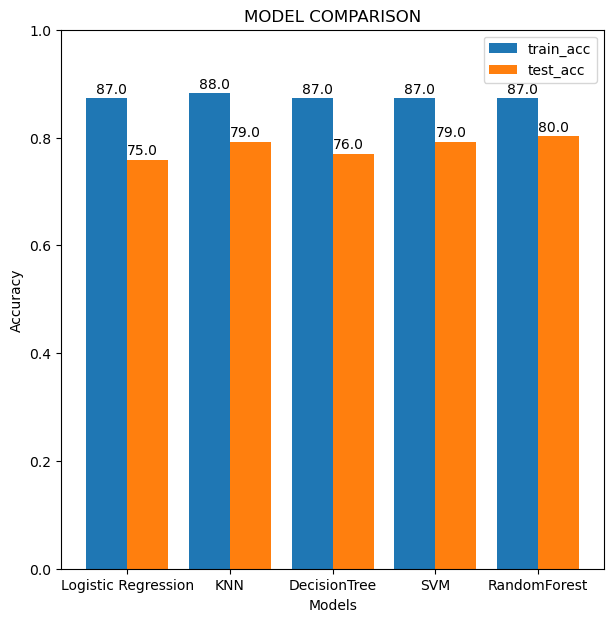

In [148]:
X=np.array([1,2,3,4,5])
name=["Logistic Regression","KNN","DecisionTree","SVM","RandomForest"]
test_acc=[LR_test,KNN_test,DT_test,SVM_test,RF_test]
train_acc=[LR_train,KNN_train,DT_train,SVM_train,RF_train]

width=0.40
plt.figure(figsize=(7,7))
plt.bar( X- width/2, train_acc,width,label="train_acc")
plt.bar( X+ width/2, test_acc,width,label="test_acc")
plt.title("MODEL COMPARISON")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(X ,name)
plt.legend()
# adding Text  plt.text(x_pos , y_pos , text in string , alignment (ha))
for i in range(len(name)):
    plt.text(X[i],train_acc[i]+0.01,str(train_acc[i]*100//1),ha="right")
    plt.text(X[i],test_acc[i]+0.01,str(test_acc[i]*100//1),ha="left")
plt.savefig("bestmodel.jpg")

# GOT THE BEST MODEL | RandomForest
- training accuracy : 87 %
- testing accuracy : 80 %